Saved subject-wise EEG data
Number of subjects: 9
Example subject EEG shape: (287, 3, 1001)
Example subject label shape: (287,)


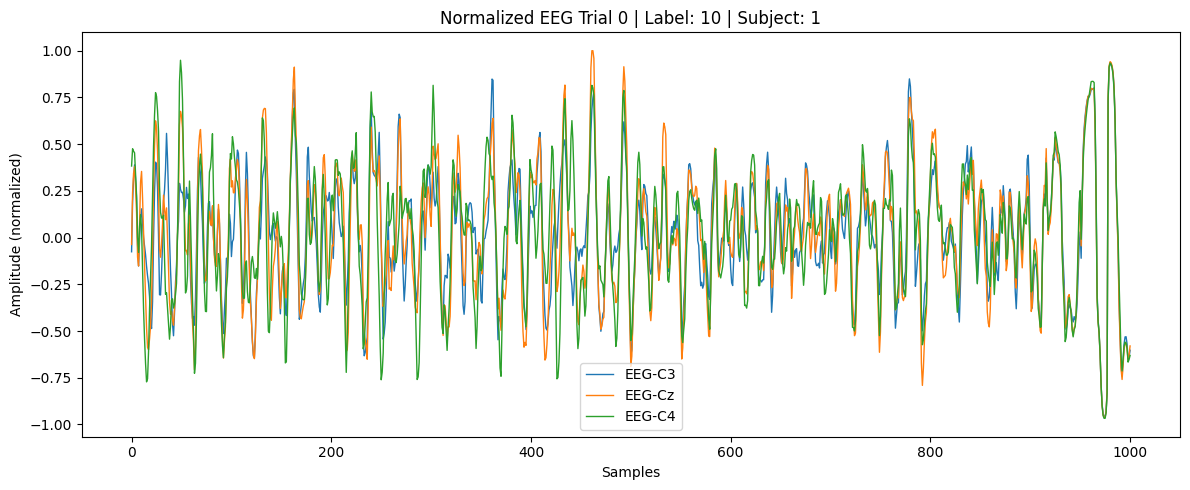

In [ ]:
# ==========================================
# PHASE 1: PREPROCESS ALL SUBJECTS
# BCI Competition IV Dataset 2a
# Channels: C3, Cz, C4
# ==========================================

import warnings
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Suppress known non-critical channel-type warning from GDF reader
warnings.filterwarnings(
    "ignore",
    message="Could not determine channel type of the following channels, they will be set as EEG:*"
 )

# Will store data from all subjects
all_X = []
all_y = []
all_subject_ids = []

# Loop through subjects 1 to 9
for subject in range(1, 10):

    # Creates filenames:
    # A01T.gdf, A02T.gdf, ..., A09T.gdf
    file_path = f"BCICIV_2a_gdf\\A{subject:02d}T.gdf"

    # Load EEG recording (suppress reader warnings)
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose="ERROR")

    # Explicitly mark known EOG channels when present
    eog_channels = ["EOG-left", "EOG-central", "EOG-right"]
    present_eog = {ch: "eog" for ch in eog_channels if ch in raw.ch_names}
    if present_eog:
        raw.set_channel_types(present_eog)

    # Keep only motor cortex channels
    raw.pick(["EEG-C3", "EEG-Cz", "EEG-C4"])

    # Motor imagery frequency range       (alpha, beta, gamma)
    raw.filter(8, 30, verbose="ERROR")

    # Extract event markers
    events, event_dict = mne.events_from_annotations(raw, verbose="ERROR")

    # Keep only motor imagery events
    available_events = {
        k: v for k, v in event_dict.items()
        if k in ["769", "770", "771", "772"]
    }

    # Create trials from 2s to 6s after cue
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=2,
        tmax=6,
        baseline=None,
        preload=True,
        verbose="ERROR"
    )

    # EEG data
    X = epochs.get_data()

    # Labels
    y = epochs.events[:, 2]

    # Normalize within each subject before saving it
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_flat = X.reshape(-1, X.shape[-1])
    X_norm = scaler.fit_transform(X_flat)
    X_norm = X_norm.reshape(X.shape)

    # Store current subject and per-trial subject labels
    all_X.append(X_norm)
    all_y.append(y)
    all_subject_ids.append(np.full(len(y), subject, dtype=np.int64))


# Save each subject separately instead of pooling them into one global array
X_subjects = np.array(all_X, dtype=object)
y_subjects = np.array(all_y, dtype=object)
subject_ids = np.array(all_subject_ids, dtype=object)

np.save("X_subjects.npy", X_subjects, allow_pickle=True)
np.save("y_subjects.npy", y_subjects, allow_pickle=True)
np.save("subject_ids.npy", subject_ids, allow_pickle=True)

print("Saved subject-wise EEG data")
print("Number of subjects:", len(X_subjects))
print("Example subject EEG shape:", X_subjects[0].shape)
print("Example subject label shape:", y_subjects[0].shape)

# visualization: first trial, all three channels
trial_idx = 0
channel_names = ["EEG-C3", "EEG-Cz", "EEG-C4"]

plt.figure(figsize=(12, 5))
for ch_idx, ch_name in enumerate(channel_names):
    plt.plot(all_X[0][trial_idx, ch_idx, :], label=ch_name, linewidth=1.0)

plt.title(f"Normalized EEG Trial {trial_idx} | Label: {all_y[0][trial_idx]} | Subject: {all_subject_ids[0][trial_idx]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.tight_layout()
plt.show()

### PHASE 2: BASELINE CNN CLASSIFIER

In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    AveragePooling2D,
    BatchNormalization,
    Activation,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.constraints import max_norm

In [17]:
# ------------------------------------------
# STEP 1: LOAD DATA
# ------------------------------------------

X_subjects = np.load("X_subjects.npy", allow_pickle=True)
y_subjects = np.load("y_subjects.npy", allow_pickle=True)

print("Loaded subject-wise EEG data")
print("Number of subjects:", len(X_subjects))

WINDOW_LENGTH = 256
WINDOW_STEP = 128

def remap_labels(y_values):
    y_values = np.asarray(y_values, dtype=np.int64)
    unique_codes = np.sort(np.unique(y_values))
    if np.array_equal(unique_codes, np.arange(len(unique_codes))):
        return y_values
    if len(unique_codes) != 4:
        raise ValueError(f"Unexpected subject labels: {unique_codes}")
    label_map = {code: idx for idx, code in enumerate(unique_codes)}
    return np.array([label_map[int(value)] for value in y_values], dtype=np.int64)

def make_windows(X_trials, y_trials, window_length, window_step):
    windows = []
    labels = []
    for trial_x, trial_y in zip(X_trials, y_trials):
        trial_length = trial_x.shape[-1]
        for start in range(0, trial_length - window_length + 1, window_step):
            window = trial_x[:, start:start + window_length].T
            windows.append(window)
            labels.append(trial_y)
    return np.asarray(windows, dtype=np.float32), np.asarray(labels, dtype=np.int64)

def predict_trials(model, X_trials, window_length, window_step):
    trial_probs = []
    for trial_x in X_trials:
        trial_windows = []
        for start in range(0, trial_x.shape[-1] - window_length + 1, window_step):
            window = trial_x[:, start:start + window_length].T
            trial_windows.append(window)
        trial_windows = np.asarray(trial_windows, dtype=np.float32)
        trial_probs.append(model.predict(trial_windows, verbose=0).mean(axis=0))
    return np.asarray(trial_probs)

subject_results = []

for subject_idx, (X_subject, y_subject) in enumerate(zip(X_subjects, y_subjects), start=1):
    print(f"\n==============================")
    print(f"Training subject {subject_idx:02d}")
    print(f"==============================")

    X_subject = X_subject.astype(np.float32)
    y_subject = remap_labels(y_subject)

    # Per-trial, per-channel z-score normalization.
    X_subject = (X_subject - X_subject.mean(axis=2, keepdims=True)) / (X_subject.std(axis=2, keepdims=True) + 1e-8)
    X_subject = np.nan_to_num(X_subject)

    print("Subject data shape:", X_subject.shape)
    print("Subject labels:", np.unique(y_subject, return_counts=True))

    X_train_trials, X_test_trials, y_train_trials, y_test_trials = train_test_split(
        X_subject,
        y_subject,
        test_size=0.2,
        random_state=42,
        stratify=y_subject
    )

    X_train, y_train = make_windows(X_train_trials, y_train_trials, WINDOW_LENGTH, WINDOW_STEP)
    X_test, y_test = make_windows(X_test_trials, y_test_trials, WINDOW_LENGTH, WINDOW_STEP)

    class_labels = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=class_labels,
        y=y_train
    )
    class_weight_dict = dict(zip(class_labels, class_weights))

    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=X_train.shape[1:]),
        GaussianNoise(0.02),
        Conv1D(64, kernel_size=7, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(128, kernel_size=5, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
    ]

    model.fit(
        X_train,
        y_train,
        epochs=80,
        batch_size=64,
        validation_split=0.2,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )

    y_pred_probs = predict_trials(model, X_test_trials, WINDOW_LENGTH, WINDOW_STEP)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_test_trials, y_pred)
    prec = precision_score(y_test_trials, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test_trials, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test_trials, y_pred, average="macro", zero_division=0)

    subject_results.append({
        "subject": int(subject_idx),
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1)
    })

    # print("Results for subject", f"{subject_idx:02d}")
X_subjects = np.load("X_subjects.npy", allow_pickle=True)
y_subjects = np.load("y_subjects.npy", allow_pickle=True)

print("Loaded subject-wise EEG data")
print("Number of subjects:", len(X_subjects))

def remap_labels(y_values):
    y_values = np.asarray(y_values, dtype=np.int64)
    unique_codes = np.sort(np.unique(y_values))
    if np.array_equal(unique_codes, np.arange(len(unique_codes))):
        return y_values
    if len(unique_codes) != 4:
        raise ValueError(f"Unexpected subject labels: {unique_codes}")
    label_map = {code: idx for idx, code in enumerate(unique_codes)}
    return np.array([label_map[int(value)] for value in y_values], dtype=np.int64)

subject_results = []

for subject_idx, (X_subject, y_subject) in enumerate(zip(X_subjects, y_subjects), start=1):
    print(f"\n==============================")
    print(f"Training subject {subject_idx:02d}")
    print(f"==============================")

    X_subject = X_subject.astype(np.float32)
    y_subject = remap_labels(y_subject)
    X_subject = (X_subject - X_subject.mean(axis=2, keepdims=True)) / (X_subject.std(axis=2, keepdims=True) + 1e-8)
    X_subject = np.nan_to_num(X_subject)
    X_subject = X_subject[..., np.newaxis]

    print("Subject data shape:", X_subject.shape)
    print("Subject labels:", np.unique(y_subject, return_counts=True))

    X_train, X_test, y_train, y_test = train_test_split(
        X_subject,
        y_subject,
        test_size=0.2,
        random_state=42,
        stratify=y_subject
    )

    class_labels = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=class_labels,
        y=y_train
    )
    class_weight_dict = dict(zip(class_labels, class_weights))

    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=X_train.shape[1:]),
        Conv2D(8, (1, 64), padding="same", use_bias=False),
        BatchNormalization(),
        DepthwiseConv2D((3, 1), use_bias=False, depth_multiplier=2, depthwise_constraint=max_norm(1.0)),
        BatchNormalization(),
        Activation("elu"),
        AveragePooling2D((1, 4)),
        Dropout(0.3),

        SeparableConv2D(16, (1, 16), padding="same", use_bias=False),
        BatchNormalization(),
        Activation("elu"),
        AveragePooling2D((1, 4)),
        Dropout(0.3),

        GlobalAveragePooling2D(),
        Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
    ]

    model.fit(
        X_train,
        y_train,
        epochs=80,
        batch_size=32,
        validation_split=0.2,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    subject_results.append({
        "subject": int(subject_idx),
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1)
    })

    print("Results for subject", f"{subject_idx:02d}")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

results_array = np.array([[r["accuracy"], r["precision"], r["recall"], r["f1"]] for r in subject_results])

print("\n==============================")
print("SUBJECT-WISE SUMMARY")
print("==============================")
print("Mean accuracy :", results_array[:, 0].mean())
print("Mean precision:", results_array[:, 1].mean())
print("Mean recall   :", results_array[:, 2].mean())
print("Mean F1 Score :", results_array[:, 3].mean())
print("\nPer-subject results:")
for result in subject_results:
    print(result)

Loaded subject-wise EEG data
Number of subjects: 9

Training subject 01
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([71, 72, 72, 72]))

Training subject 02
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([72, 72, 71, 72]))

Training subject 03
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([72, 72, 71, 72]))

Training subject 04
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([71, 72, 72, 72]))

Training subject 05
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([72, 72, 71, 72]))

Training subject 06
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([72, 72, 71, 72]))

Training subject 07
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([72, 72, 71, 72]))

Training subject 08
Subject data shape: (287, 3, 1001)
Subject labels: (array([0, 1, 2, 3]), array([72, 72, 71, 72]